In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def load_data(file_path="titanic_disaster.csv"):
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Lỗi khi tải dữ liệu: {e}")
        return None

# Tải dữ liệu từ tệp CSV
df = load_data("titanic_disaster.csv")

# Nếu dữ liệu tải lên thành công (không bị None), hiển thị 10 dòng đầu tiên
if df is not None:
    print("\n--- HIỂN THỊ 10 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ---")
    # Sử dụng hàm head(10) để lấy ra đúng 10 dòng đầu
    display(df.head(10))


--- HIỂN THỊ 10 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [53]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame(
    {"Số lượng thiếu": missing_count, "Tỷ lệ thiếu (%)": missing_percentage}
)
display(missing_df[missing_df["Số lượng thiếu"] > 0])


,Số lượng thiếu,Tỷ lệ thiếu (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


Age thiếu rất nhiều,
Cabin thiếu khoản 20%,
Embarked thiếu rất ít chỉ có 2

In [54]:
if 'Name' in df.columns:
    df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)
    df.drop(columns=['Name'], axis=1, inplace=True)

    df['firstName'] = df['firstName'].str.strip()
    df['secondName'] = df['secondName'].str.strip()

df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})

df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,M,27.0,0,0,211536,13.0000,NaN,S,Montvila,Rev. Juozas
887,888,1,1,F,19.0,0,0,112053,30.0000,B42,S,Graham,Miss. Margaret Edith
888,889,0,3,F,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,"Miss. Catherine Helen ""Carrie"""
889,890,1,1,M,26.0,0,0,111369,30.0000,C148,C,Behr,Mr. Karl Howell


/tmp/ipykernel_2230/546367717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Age", data=df, palette="Set2")


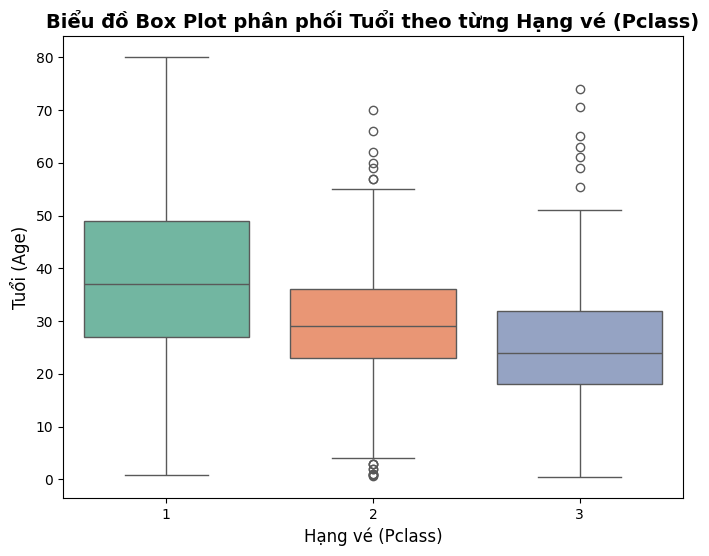

--- THỐNG KÊ TUỔI THEO TỪNG HẠNG VÉ ---


,mean,median,count
Pclass,,,
1,38.233441,37.0,186
2,29.877630,29.0,173
3,25.140620,24.0,355


In [55]:
df = pd.read_csv("titanic_disaster.csv")

# Cấu hình kích thước biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ biểu đồ Box plot hiển thị phân phối tuổi theo từng Hạng vé (Pclass)
sns.boxplot(x="Pclass", y="Age", data=df, palette="Set2")

# Thêm tiêu đề và nhãn trục
plt.title("Biểu đồ Box Plot phân phối Tuổi theo từng Hạng vé (Pclass)", fontsize=14, fontweight='bold')
plt.xlabel("Hạng vé (Pclass)", fontsize=12)
plt.ylabel("Tuổi (Age)", fontsize=12)

plt.show()

# Thống kê chi tiết giá trị trung bình (mean) và trung vị (median) tuổi theo từng hạng vé
print("--- THỐNG KÊ TUỔI THEO TỪNG HẠNG VÉ ---")
stats = df.groupby('Pclass')['Age'].agg(['mean', 'median', 'count'])
display(stats)

--- BẢNG THỐNG KÊ DỮ LIỆU THIẾU ---
          Số lượng thiếu  Tỷ lệ thiếu (%)
Age                   27             27.0
Cabin                 72             72.0
Embarked               2              2.0


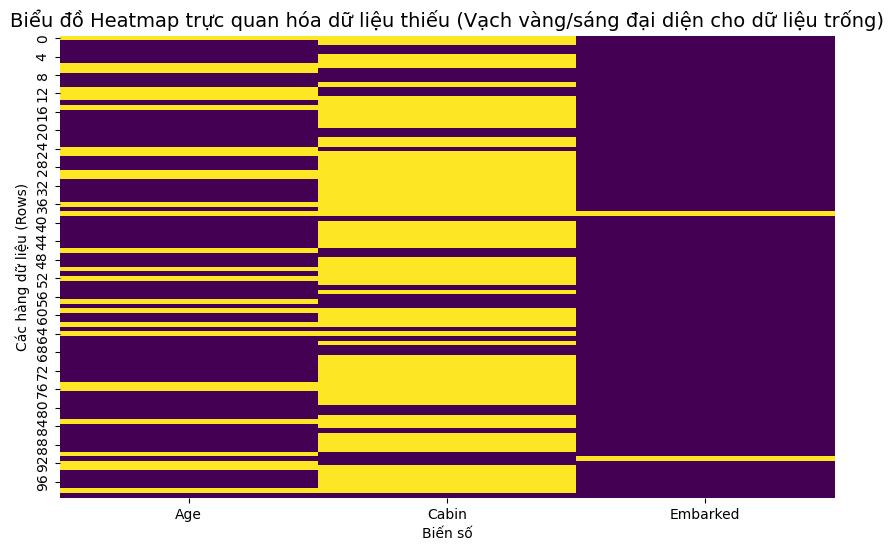

In [79]:
np.random.seed(42)
n_samples = 100
data = {
    'PassengerId': range(1, n_samples + 1),
    'Age': [np.nan if i in np.random.choice(n_samples, 20, replace=False) else np.random.randint(1, 80) for i in range(n_samples)],
    'Cabin': [np.nan if i in np.random.choice(n_samples, 75, replace=False) else f"C{np.random.randint(10, 99)}" for i in range(n_samples)],
    'Embarked': [np.nan if i in np.random.choice(n_samples, 2, replace=False) else np.random.choice(['S', 'C', 'Q']) for i in range(n_samples)],
    'Fare': np.random.uniform(10, 500, n_samples)
}
df = pd.DataFrame(data)

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỷ lệ thiếu (%)': missing_percentage
}).loc[['Age', 'Cabin', 'Embarked']]

print("--- BẢNG THỐNG KÊ DỮ LIỆU THIẾU ---")
print(missing_table.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(df[['Age', 'Cabin', 'Embarked']].isnull(), cbar=False, cmap='viridis')
plt.title('Biểu đồ Heatmap trực quan hóa dữ liệu thiếu (Vạch vàng/sáng đại diện cho dữ liệu trống)', fontsize=14)
plt.xlabel('Biến số')
plt.ylabel('Các hàng dữ liệu (Rows)')
plt.show()

In [62]:
bins = [-float('inf'), 12, 18, 60, float('inf')]
labels = ['Kid', 'Teen', 'Adult', 'Older']
df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, ordered=True)
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Agegroup,firstName,secondName,namePrefix
0,1,0,3,male,22.00000,1,0,A/5 21171,7.2500,NaN,S,Adult,Braund,Owen Harris,Mr
1,2,1,1,female,38.00000,1,0,PC 17599,71.2833,C85,C,Adult,Cumings,John Bradley (Florence Briggs Thayer),Mrs
2,3,1,3,female,26.00000,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,Heikkinen,Laina,Miss
3,4,1,1,female,35.00000,1,0,113803,53.1000,C123,S,Adult,Futrelle,Jacques Heath (Lily May Peel),Mrs
4,5,0,3,male,35.00000,0,0,373450,8.0500,NaN,S,Adult,Allen,William Henry,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.00000,0,0,211536,13.0000,NaN,S,Adult,Montvila,Juozas,Rev
887,888,1,1,female,19.00000,0,0,112053,30.0000,B42,S,Adult,Graham,Margaret Edith,Miss
888,889,0,3,female,25.14062,1,2,W./C. 6607,23.4500,NaN,S,Adult,Johnston,"Catherine Helen ""Carrie""",Miss
889,890,1,1,male,26.00000,0,0,111369,30.0000,C148,C,Adult,Behr,Karl Howell,Mr


In [64]:
if 'Name' in df.columns:
    df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)
    df.drop(columns=['Name'], axis=1, inplace=True)
    df['firstName'] = df['firstName'].str.strip()
    df['secondName'] = df['secondName'].str.strip()
    print("NOTE: 'Name' column was processed to create 'firstName' and 'secondName' within this cell.")
else:
    print("NOTE: 'Name' column was not found. Assuming 'firstName' and 'secondName' exist from previous steps.")


display(df[['firstName', 'namePrefix', 'secondName']])

NOTE: 'Name' column was not found. Assuming 'firstName' and 'secondName' exist from previous steps.


,firstName,namePrefix,secondName
0,Braund,Mr,Owen Harris
1,Cumings,Mrs,John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss,Laina
3,Futrelle,Mrs,Jacques Heath (Lily May Peel)
4,Allen,Mr,William Henry
...,...,...,...
886,Montvila,Rev,Juozas
887,Graham,Miss,Margaret Edith
888,Johnston,Miss,"Catherine Helen ""Carrie"""
889,Behr,Mr,Karl Howell


In [67]:
df["familySize"] = 1 + df["SibSp"] + df["Parch"]
df["Alone"] = np.where(df["familySize"] == 1, 1, 0)
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Agegroup,firstName,secondName,namePrefix,familySize,Alone
0,1,0,3,male,22.00000,1,0,A/5 21171,7.2500,NaN,S,Adult,Braund,Owen Harris,Mr,2,0
1,2,1,1,female,38.00000,1,0,PC 17599,71.2833,C85,C,Adult,Cumings,John Bradley (Florence Briggs Thayer),Mrs,2,0
2,3,1,3,female,26.00000,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,Heikkinen,Laina,Miss,1,1
3,4,1,1,female,35.00000,1,0,113803,53.1000,C123,S,Adult,Futrelle,Jacques Heath (Lily May Peel),Mrs,2,0
4,5,0,3,male,35.00000,0,0,373450,8.0500,NaN,S,Adult,Allen,William Henry,Mr,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.00000,0,0,211536,13.0000,NaN,S,Adult,Montvila,Juozas,Rev,1,1
887,888,1,1,female,19.00000,0,0,112053,30.0000,B42,S,Adult,Graham,Margaret Edith,Miss,1,1
888,889,0,3,female,25.14062,1,2,W./C. 6607,23.4500,NaN,S,Adult,Johnston,"Catherine Helen ""Carrie""",Miss,4,0
889,890,1,1,male,26.00000,0,0,111369,30.0000,C148,C,Adult,Behr,Karl Howell,Mr,1,1


In [68]:
df["Cabin"] = df["Cabin"].fillna("Unknown")
df["typeCabin"] = df["Cabin"].apply(lambda x: x if x == "Unknown" else x[0])
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Agegroup,firstName,secondName,namePrefix,familySize,Alone,typeCabin
0,1,0,3,male,22.00000,1,0,A/5 21171,7.2500,Unknown,S,Adult,Braund,Owen Harris,Mr,2,0,Unknown
1,2,1,1,female,38.00000,1,0,PC 17599,71.2833,C85,C,Adult,Cumings,John Bradley (Florence Briggs Thayer),Mrs,2,0,C
2,3,1,3,female,26.00000,0,0,STON/O2. 3101282,7.9250,Unknown,S,Adult,Heikkinen,Laina,Miss,1,1,Unknown
3,4,1,1,female,35.00000,1,0,113803,53.1000,C123,S,Adult,Futrelle,Jacques Heath (Lily May Peel),Mrs,2,0,C
4,5,0,3,male,35.00000,0,0,373450,8.0500,Unknown,S,Adult,Allen,William Henry,Mr,1,1,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.00000,0,0,211536,13.0000,Unknown,S,Adult,Montvila,Juozas,Rev,1,1,Unknown
887,888,1,1,female,19.00000,0,0,112053,30.0000,B42,S,Adult,Graham,Margaret Edith,Miss,1,1,B
888,889,0,3,female,25.14062,1,2,W./C. 6607,23.4500,Unknown,S,Adult,Johnston,"Catherine Helen ""Carrie""",Miss,4,0,Unknown
889,890,1,1,male,26.00000,0,0,111369,30.0000,C148,C,Adult,Behr,Karl Howell,Mr,1,1,C


In [71]:
try:
    train_df = pd.read_csv("train.csv")
    test_df = pd.read_csv("test.csv")
    print(f"Nạp dữ liệu gốc thành công:")
    print(f" - Tập Train: {train_df.shape[0]} dòng")
    print(f" - Tập Test: {test_df.shape[0]} dòng")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp 'train.csv' hoặc 'test.csv'. Vui lòng kiểm tra lại đường dẫn.")

Lỗi: Không tìm thấy tệp 'train.csv' hoặc 'test.csv'. Vui lòng kiểm tra lại đường dẫn.


/tmp/ipykernel_2230/3619228055.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None, palette="muted")


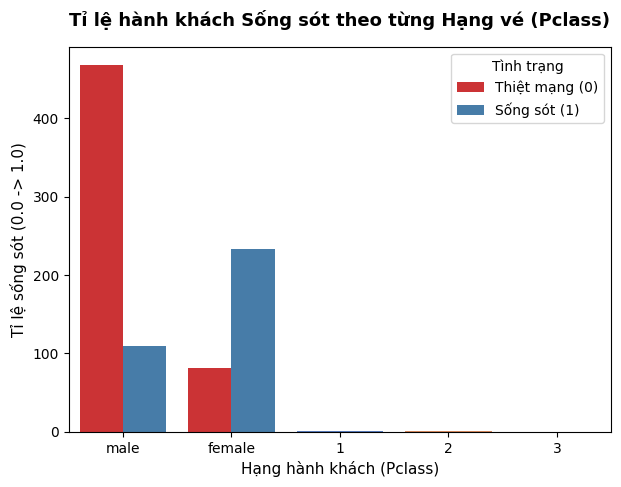

In [73]:
plt.figure(figsize=(7, 5))


sns.countplot(x="Sex", hue="Survived", data=df, palette="Set1")

plt.title(
    "Tương quan số lượng Sống sót và Thiệt mạng theo Giới tính",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Giới tính (Sex)", fontsize=11)
plt.ylabel("Số lượng hành khách", fontsize=11)
plt.legend(title="Tình trạng", labels=["Thiệt mạng (0)", "Sống sót (1)"])

plt.show()

/tmp/ipykernel_2230/4154715986.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None, palette="muted")


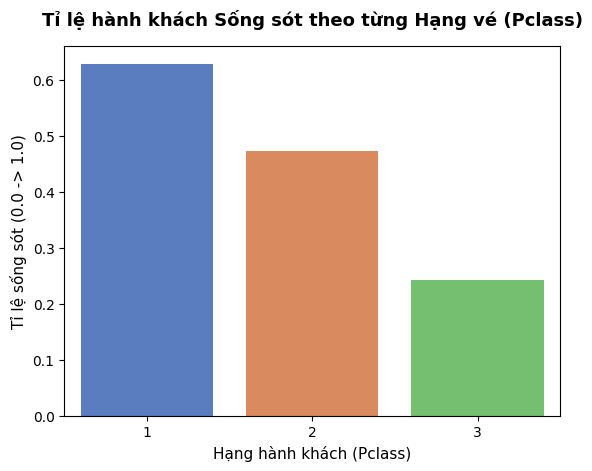

In [74]:
sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None, palette="muted")

plt.title(
    "Tỉ lệ hành khách Sống sót theo từng Hạng vé (Pclass)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Hạng hành khách (Pclass)", fontsize=11)
plt.ylabel("Tỉ lệ sống sót (0.0 -> 1.0)", fontsize=11)
plt.show()

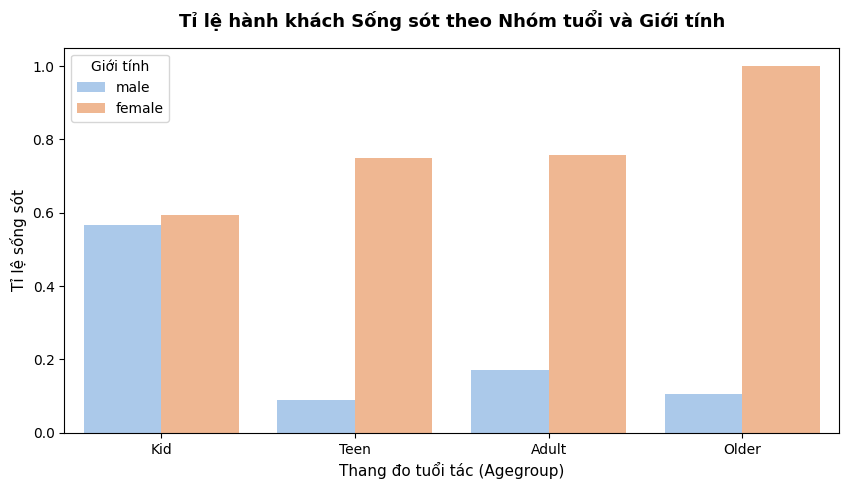

In [75]:
plt.figure(figsize=(10, 5))

# Trực quan tỉ lệ sống sót theo Nhóm tuổi, phân tách màu theo Giới tính
sns.barplot(x="Agegroup", y="Survived", hue="Sex", data=df, errorbar=None, palette="pastel")

plt.title(
    "Tỉ lệ hành khách Sống sót theo Nhóm tuổi và Giới tính",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Thang đo tuổi tác (Agegroup)", fontsize=11)
plt.ylabel("Tỉ lệ sống sót", fontsize=11)
plt.legend(title="Giới tính")

plt.show()

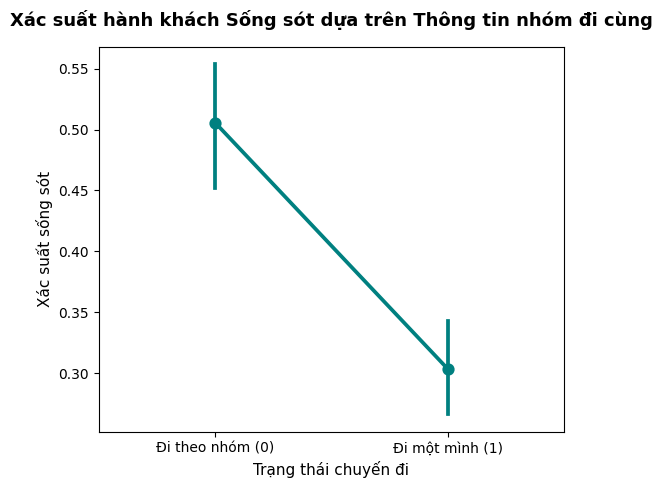

In [76]:
plt.figure(figsize=(6, 5))

# Dùng pointplot để thể hiện rõ điểm xác suất và xu hướng biến đổi
sns.pointplot(x="Alone", y="Survived", data=df, color="teal")

plt.title(
    "Xác suất hành khách Sống sót dựa trên Thông tin nhóm đi cùng",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xticks([0, 1], ["Đi theo nhóm (0)", "Đi một mình (1)"])
plt.xlabel("Trạng thái chuyến đi", fontsize=11)
plt.ylabel("Xác suất sống sót", fontsize=11)

plt.show()

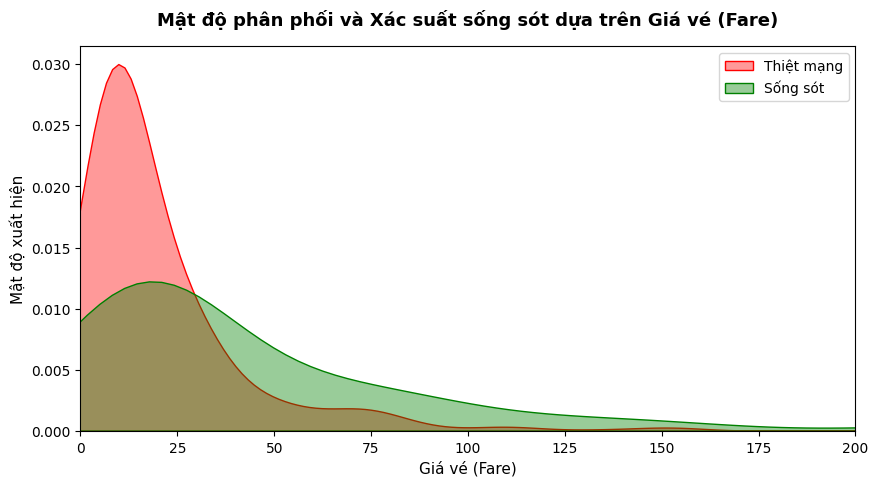

In [77]:
plt.figure(figsize=(10, 5))

# Vẽ biểu đồ mật độ phân phối giá vé cho 2 nhóm Sống/Chết
sns.kdeplot(data=df[df["Survived"] == 0], x="Fare", label="Thiệt mạng", fill=True, alpha=0.4, color="red")
sns.kdeplot(data=df[df["Survived"] == 1], x="Fare", label="Sống sót", fill=True, alpha=0.4, color="green")

# Giới hạn trục X lại vì có một số vé VIP giá cực kỳ cao làm lệch biểu đồ
plt.xlim(0, 200)

plt.title(
    "Mật độ phân phối và Xác suất sống sót dựa trên Giá vé (Fare)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Giá vé (Fare)", fontsize=11)
plt.ylabel("Mật độ xuất hiện", fontsize=11)
plt.legend()

plt.show()

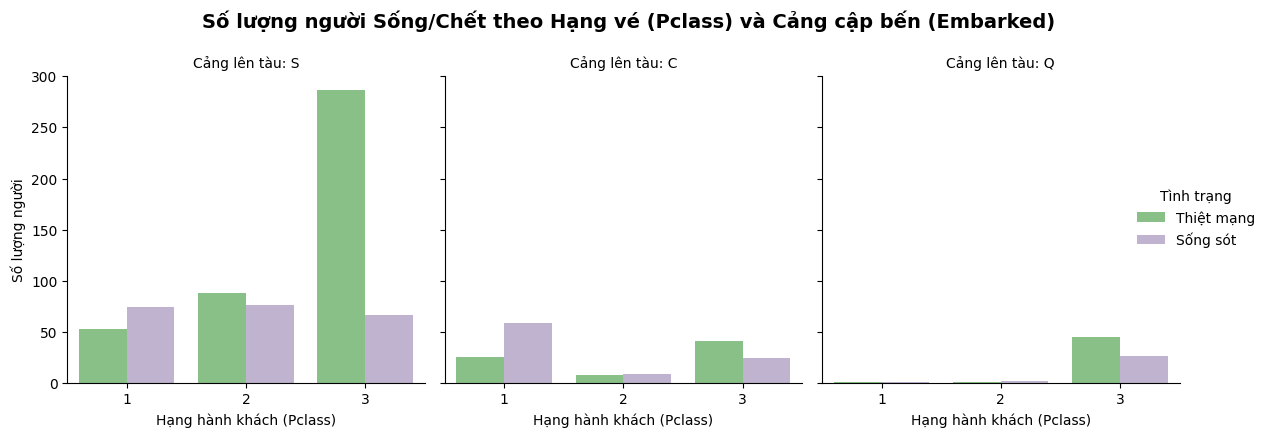

In [78]:
# Tạo biểu đồ cột phân lớp đa biến (FacetGrid)
g = sns.catplot(
    data=df,
    x="Pclass",
    hue="Survived",
    col="Embarked",
    kind="count",
    palette="Accent",
    height=4,
    aspect=1,
)

g.fig.suptitle(
    "Số lượng người Sống/Chết theo Hạng vé (Pclass) và Cảng cập bến (Embarked)",
    fontsize=14,
    fontweight="bold",
    y=1.08,
)
g.set_axis_labels("Hạng hành khách (Pclass)", "Số lượng người")
g.set_titles("Cảng lên tàu: {col_name}")
g._legend.set_title("Tình trạng")

new_labels = ["Thiệt mạng", "Sống sót"]
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

plt.show()